# ListenBrainz Data Exploration & Quality Analysis

This notebook provides comprehensive exploratory data analysis (EDA) of the ListenBrainz music listening dataset stored in Postgres. It investigates:
- **Data coverage**: temporal distribution, date ranges
- **Entities**: unique artists/tracks per day, aggregate listen counts
- **Distributions**: long-tails, sparsity patterns
- **Quality**: missing values, data validity checks
- **Insights**: implications for downstream modeling

The analysis helps identify potential issues affecting model performance (class imbalance, cold-start, distribution shifts, etc.).

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# Ensure dependencies are installed
import subprocess
subprocess.run([sys.executable, "-m", "pip", "-q", "install", 
                "psycopg2-binary", "pandas", "matplotlib", "seaborn", "numpy"], 
               check=False)

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Dependencies loaded")

✓ Dependencies loaded


In [2]:
import importlib
import sys
from pathlib import Path

# Add parent dir to path so we can import local modules
sys.path.insert(0, str(Path.cwd().parent))

# Force-reload to pick up any changes since the kernel started
import pipeline, utils
importlib.reload(utils)
importlib.reload(pipeline)

from utils import connect_postgres

# Test connection
try:
    conn = connect_postgres()
    with conn.cursor() as cur:
        cur.execute("SELECT version();")
        print(f"\n✓ Connection successful")
        print(f"  {cur.fetchone()[0][:80]}...")
    conn.close()
except Exception as e:
    print(f"✗ Connection failed: {e}")


✓ Connection successful
  PostgreSQL 17.4 on aarch64-unknown-linux-gnu, compiled by aarch64-unknown-linux-...


## Phase 1: Database Metadata & Scope

In [3]:
print("=" * 80)
print("PHASE 1: DATABASE METADATA")
print("=" * 80)

conn = connect_postgres()
with conn.cursor() as cur:
    # Get table metadata
    tables = [
        "artist_info",
        "track_info", 
        "artist_daily_listens",
        "track_daily_listens",
        "artist_daily_stats",
        "track_daily_stats",
        "ingestion_state"
    ]
    
    table_metadata = {}
    for table in tables:
        cur.execute(f"SELECT COUNT(*) FROM {table};")
        count = cur.fetchone()[0]
        
        cur.execute(f"""
            SELECT column_name, data_type 
            FROM information_schema.columns 
            WHERE table_name = %s 
            ORDER BY ordinal_position;
        """, (table,))
        columns = cur.fetchall()
        
        table_metadata[table] = {
            "row_count": count,
            "columns": columns
        }

conn.close()

# Display table overview
metadata_df = pd.DataFrame([
    {"Table": table, "Row Count": meta["row_count"]}
    for table, meta in table_metadata.items()
])

print("\nTable Sizes:")
print(metadata_df.to_string(index=False))

# Detail column info
print("\nTable Schemas:")
for table in tables:
    meta = table_metadata[table]
    print(f"\n  {table} ({meta['row_count']:,} rows)")
    for col_name, col_type in meta["columns"]:
        print(f"    - {col_name}: {col_type}")

PHASE 1: DATABASE METADATA

Table Sizes:
               Table  Row Count
         artist_info      29552
          track_info    1285463
artist_daily_listens      45261
 track_daily_listens    6815895
  artist_daily_stats      45261
   track_daily_stats    6815895
     ingestion_state          1

Table Schemas:

  artist_info (29,552 rows)
    - artist_mbid: text
    - artist_name: text

  track_info (1,285,463 rows)
    - recording_id: text
    - track_name: text
    - artist_mbids: ARRAY
    - release_name: text

  artist_daily_listens (45,261 rows)
    - day: date
    - artist_mbid: text
    - listen_count: bigint

  track_daily_listens (6,815,895 rows)
    - day: date
    - recording_id: text
    - listen_count: bigint

  artist_daily_stats (45,261 rows)
    - day: date
    - artist_mbid: text
    - growth_percentile: double precision
    - cumulative_listen_count: bigint
    - listen_count_past_7_days: bigint
    - listen_pctl_past_7_days: double precision
    - listen_count_past_

In [5]:
print("\n" + "=" * 80)
print("DATE RANGE AND DATA SCOPE")
print("=" * 80)

conn = connect_postgres()
with conn.cursor() as cur:
    # Date range for daily tables
    cur.execute("""
        SELECT MIN(day), MAX(day), COUNT(DISTINCT day) 
        FROM artist_daily_listens;
    """)
    min_day, max_day, num_days = cur.fetchone()
    print(f"\nDate Coverage (artist_daily_listens):")
    print(f"  From: {min_day}")
    print(f"  To:   {max_day}")
    print(f"  Days with data: {num_days}")
    
    cur.execute("""
        SELECT MIN(day), MAX(day), COUNT(DISTINCT day) 
        FROM track_daily_listens;
    """)
    min_day_t, max_day_t, num_days_t = cur.fetchone()
    print(f"\nDate Coverage (track_daily_listens):")
    print(f"  From: {min_day_t}")
    print(f"  To:   {max_day_t}")
    print(f"  Days with data: {num_days_t}")
    
    # Total listens
    cur.execute("SELECT SUM(listen_count) FROM artist_daily_listens;")
    total_listens = cur.fetchone()[0]
    print(f"\nTotal Listens: {total_listens:,}")

conn.close()


DATE RANGE AND DATA SCOPE

Date Coverage (artist_daily_listens):
  From: 2012-07-13
  To:   2026-01-19
  Days with data: 116

Date Coverage (track_daily_listens):
  From: 2005-02-13
  To:   2026-01-19
  Days with data: 7353

Total Listens: 212,162


## Phase 2: Data Quality & Completeness

**Note:** This dataset was pre-filtered during ingestion to remove rows with missing values in key fields. The analysis below is included for completeness and should show minimal/zero missing values.

In [6]:
from psycopg2 import sql

print("\n" + "=" * 80)
print("PHASE 2: DATA QUALITY & COMPLETENESS")
print("=" * 80)

print("""
NOTE: This dataset was pre-filtered during ingestion to remove rows with 
missing values in key fields (recording_id, artist_mbid, timestamp, etc.).
Null/missing value analysis below is included for completeness and should 
show minimal results.
""")


conn = connect_postgres()

missing_values = {}
target_tables = ["artist_info", "track_info", "artist_daily_listens", "track_daily_listens"]

with conn.cursor() as cur:
    for table in target_tables:
        # Get columns for this table
        cur.execute("""
            SELECT column_name
            FROM information_schema.columns
            WHERE table_schema = 'public' AND table_name = %s
            ORDER BY ordinal_position;
        """, (table,))
        table_columns = [r[0] for r in cur.fetchall()]

        # Count nulls per column safely
        table_nulls = {}
        for col in table_columns:
            cur.execute(
                sql.SQL("SELECT COUNT(*) FROM {} WHERE {} IS NULL;").format(
                    sql.Identifier(table),
                    sql.Identifier(col)
                )
            )
            table_nulls[col] = cur.fetchone()[0]

        missing_values[table] = table_nulls

conn.close()

print("\nNull Value Counts by Table:")
for table, nulls in missing_values.items():
    print(f"\n  {table}:")
    if not any(nulls.values()):
        print("    ✓ No missing values")
    else:
        for col, count in nulls.items():
            if count > 0:
                print(f"    - {col}: {count}")


PHASE 2: DATA QUALITY & COMPLETENESS

NOTE: This dataset was pre-filtered during ingestion to remove rows with 
missing values in key fields (recording_id, artist_mbid, timestamp, etc.).
Null/missing value analysis below is included for completeness and should 
show minimal results.


Null Value Counts by Table:

  artist_info:
    ✓ No missing values

  track_info:
    - release_name: 93855

  artist_daily_listens:
    ✓ No missing values

  track_daily_listens:
    ✓ No missing values


## Phase 3: Time Series Analysis


PHASE 3: TIME SERIES ANALYSIS

Loaded 116 days of listen data
Date range: 2012-07-13 to 2026-01-19


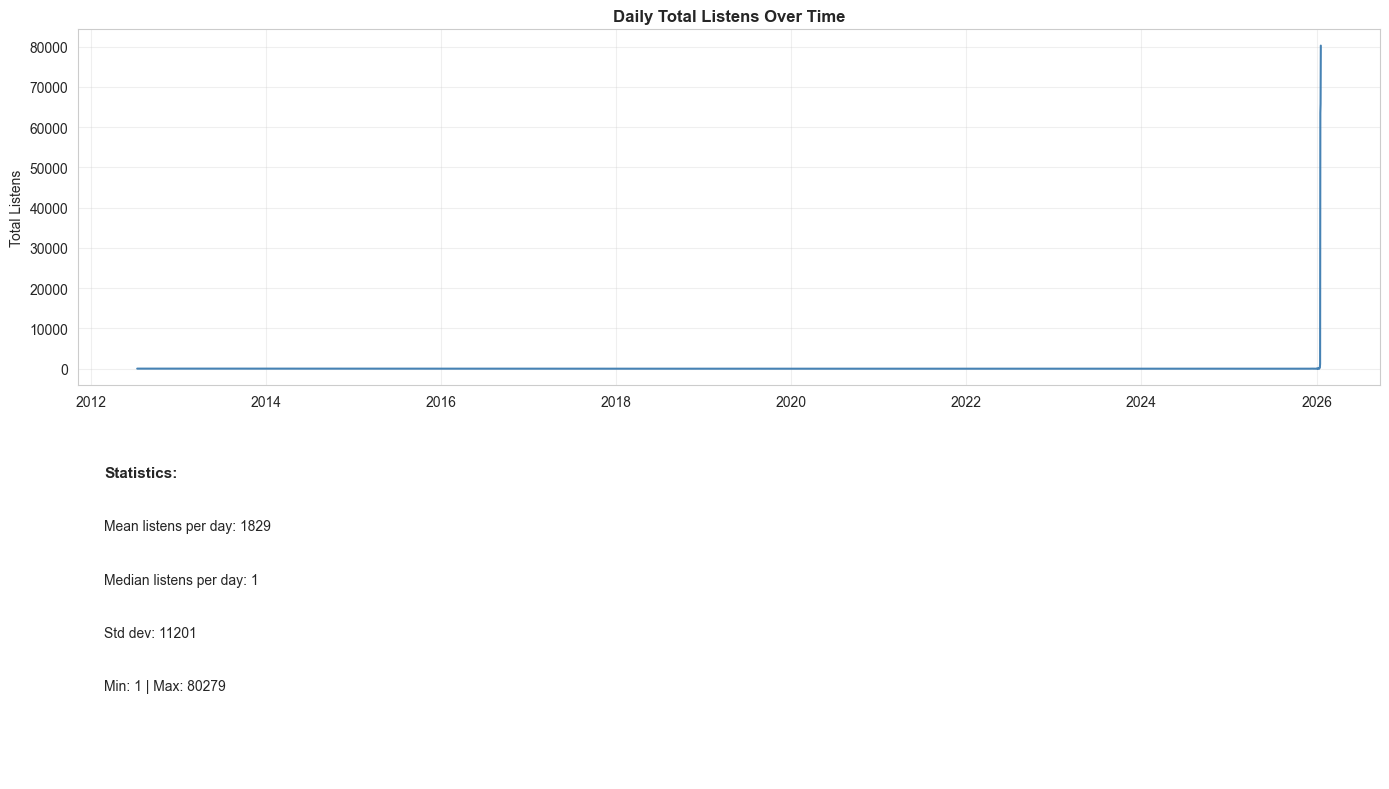


Daily Listen Summary:
count     116
unique     25
top         1
freq       64
Name: total_listens, dtype: object


In [7]:
print("\n" + "=" * 80)
print("PHASE 3: TIME SERIES ANALYSIS")
print("=" * 80)

conn = connect_postgres()

# Load daily listening trends
with conn.cursor() as cur:
    cur.execute("""
        SELECT day, SUM(listen_count) as total_listens
        FROM artist_daily_listens
        GROUP BY day
        ORDER BY day;
    """)
    daily_data = cur.fetchall()

conn.close()

df_daily = pd.DataFrame(daily_data, columns=["day", "total_listens"])
df_daily["day"] = pd.to_datetime(df_daily["day"])

print(f"\nLoaded {len(df_daily)} days of listen data")
print(f"Date range: {df_daily['day'].min().date()} to {df_daily['day'].max().date()}")

# Visualize daily trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series plot
axes[0].plot(df_daily["day"], df_daily["total_listens"], linewidth=1.5, color="steelblue")
axes[0].set_title("Daily Total Listens Over Time", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Total Listens")
axes[0].grid(True, alpha=0.3)

# Statistics
axes[1].text(0.02, 0.85, f"Statistics:", transform=axes[1].transAxes, fontsize=11, fontweight="bold")
axes[1].text(0.02, 0.70, f"Mean listens per day: {df_daily['total_listens'].mean():.0f}", 
             transform=axes[1].transAxes, fontsize=10)
axes[1].text(0.02, 0.55, f"Median listens per day: {df_daily['total_listens'].median():.0f}", 
             transform=axes[1].transAxes, fontsize=10)
axes[1].text(0.02, 0.40, f"Std dev: {pd.to_numeric(df_daily['total_listens']).std():.0f}", 
             transform=axes[1].transAxes, fontsize=10)
axes[1].text(0.02, 0.25, f"Min: {df_daily['total_listens'].min():.0f} | Max: {df_daily['total_listens'].max():.0f}", 
             transform=axes[1].transAxes, fontsize=10)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\nDaily Listen Summary:")
print(df_daily["total_listens"].describe())


DATE RANGE AND DATA SCOPE (2026-01-01 onwards)

Date Coverage (artist_daily_listens, 2026+):
  From: 2026-01-02
  To:   2026-01-19
  Days with data: 18

Date Coverage (track_daily_listens, 2026+):
  From: 2026-01-01
  To:   2026-01-19
  Days with data: 19

Total Listens (2026+): 211,940


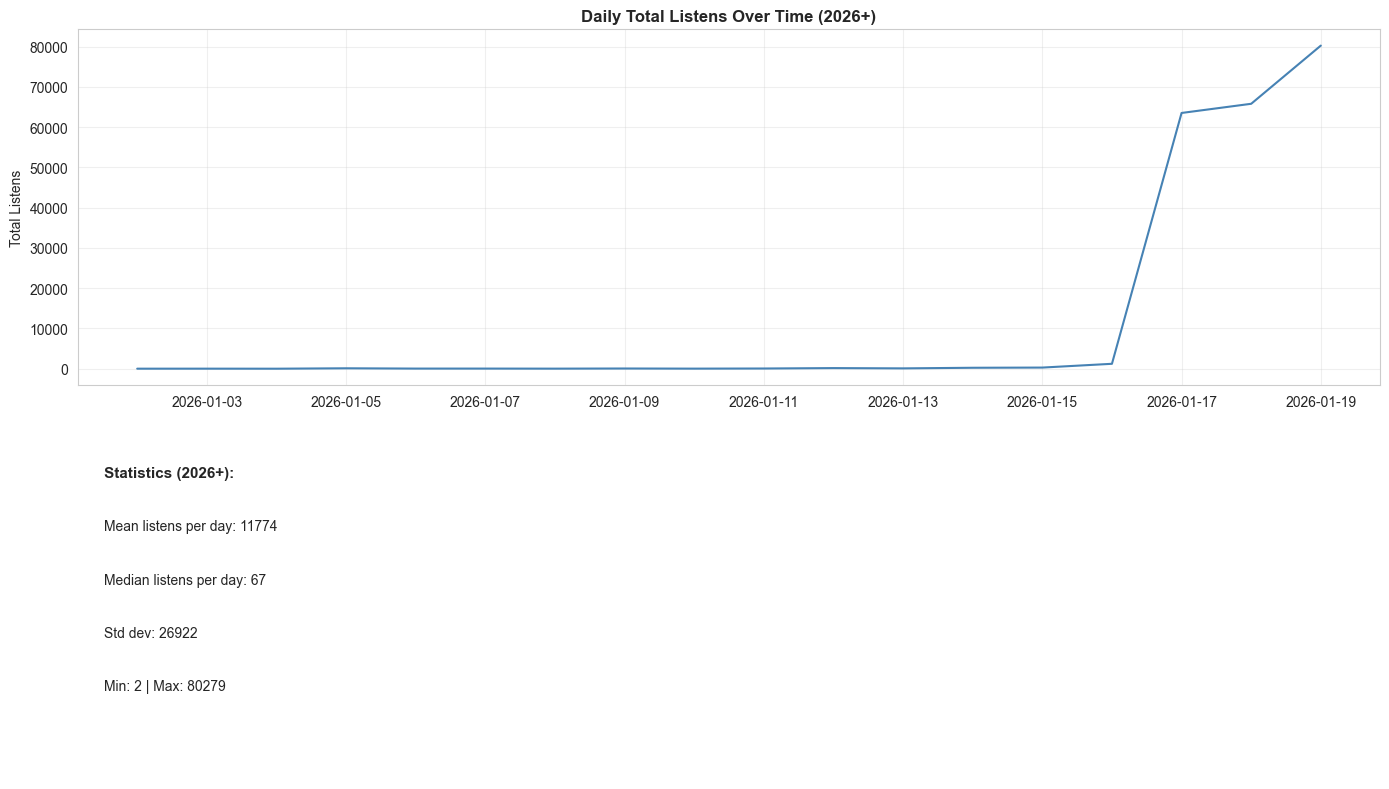


Daily Listen Summary (2026+):
count       18.000000
mean     11774.444444
std      26921.501510
min          2.000000
25%         21.750000
50%         67.000000
75%        271.000000
max      80279.000000
Name: total_listens, dtype: float64


In [8]:
print("\n" + "=" * 80)
print("DATE RANGE AND DATA SCOPE (2026-01-01 onwards)")
print("=" * 80)

conn = connect_postgres()
with conn.cursor() as cur:
    # Date range for daily tables (filtered for 2026+)
    cur.execute("""
        SELECT MIN(day), MAX(day), COUNT(DISTINCT day) 
        FROM artist_daily_listens
        WHERE day >= '2026-01-01';
    """)
    min_day, max_day, num_days = cur.fetchone()
    print(f"\nDate Coverage (artist_daily_listens, 2026+):")
    print(f"  From: {min_day}")
    print(f"  To:   {max_day}")
    print(f"  Days with data: {num_days}")
    
    cur.execute("""
        SELECT MIN(day), MAX(day), COUNT(DISTINCT day) 
        FROM track_daily_listens
        WHERE day >= '2026-01-01';
    """)
    min_day_t, max_day_t, num_days_t = cur.fetchone()
    print(f"\nDate Coverage (track_daily_listens, 2026+):")
    print(f"  From: {min_day_t}")
    print(f"  To:   {max_day_t}")
    print(f"  Days with data: {num_days_t}")
    
    # Total listens
    cur.execute("""
        SELECT SUM(listen_count) 
        FROM artist_daily_listens
        WHERE day >= '2026-01-01';
    """)
    total_listens = cur.fetchone()[0]
    print(f"\nTotal Listens (2026+): {total_listens:,}")

conn.close()

# Visualize daily trends for 2026+ data
df_daily_2026 = df_daily[df_daily['day'] >= '2026-01-01']

fig_2026, axes_2026 = plt.subplots(2, 1, figsize=(14, 8))

# Time series plot
axes_2026[0].plot(df_daily_2026["day"], df_daily_2026["total_listens"], linewidth=1.5, color="steelblue")
axes_2026[0].set_title("Daily Total Listens Over Time (2026+)", fontsize=12, fontweight="bold")
axes_2026[0].set_ylabel("Total Listens")
axes_2026[0].grid(True, alpha=0.3)

# Statistics
axes_2026[1].text(0.02, 0.85, f"Statistics (2026+):", transform=axes_2026[1].transAxes, fontsize=11, fontweight="bold")
axes_2026[1].text(0.02, 0.70, f"Mean listens per day: {df_daily_2026['total_listens'].astype(float).mean():.0f}", 
             transform=axes_2026[1].transAxes, fontsize=10)
axes_2026[1].text(0.02, 0.55, f"Median listens per day: {df_daily_2026['total_listens'].astype(float).median():.0f}", 
             transform=axes_2026[1].transAxes, fontsize=10)
axes_2026[1].text(0.02, 0.40, f"Std dev: {pd.to_numeric(df_daily_2026['total_listens']).std():.0f}", 
             transform=axes_2026[1].transAxes, fontsize=10)
axes_2026[1].text(0.02, 0.25, f"Min: {df_daily_2026['total_listens'].astype(float).min():.0f} | Max: {df_daily_2026['total_listens'].astype(float).max():.0f}", 
             transform=axes_2026[1].transAxes, fontsize=10)
axes_2026[1].axis("off")

plt.tight_layout()
plt.show()

print("\nDaily Listen Summary (2026+):")
print(pd.to_numeric(df_daily_2026["total_listens"]).describe())

## Phase 4: Artist & Track Statistics


PHASE 4: ARTIST & TRACK ANALYSIS

Artist Statistics:
  Total artists: 29,552
  Total artist-day entries: 45,261
  Average listens per artist: 7


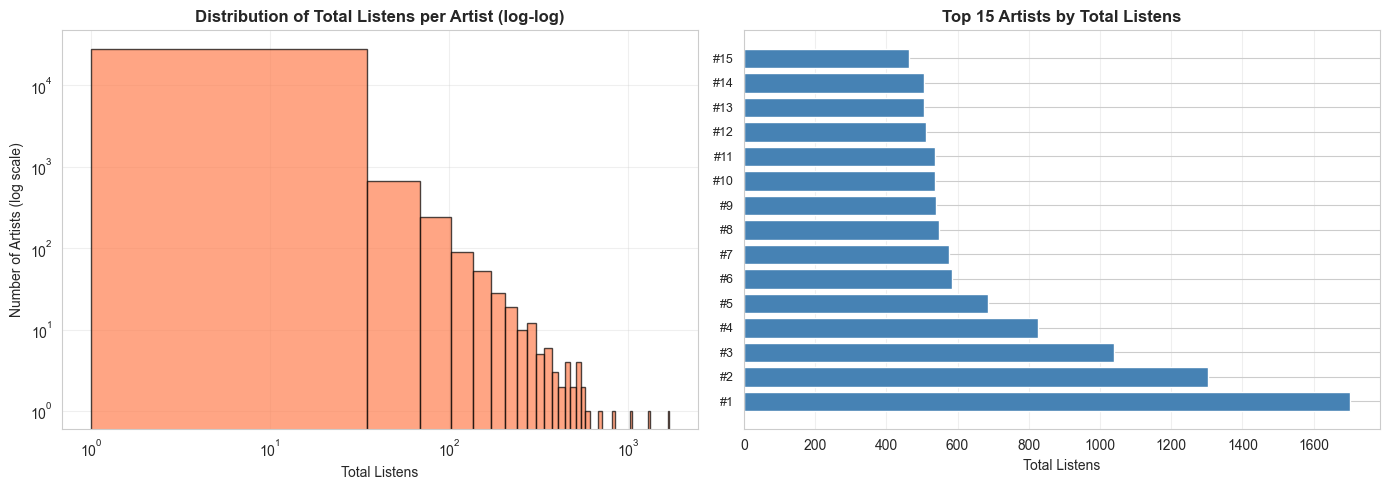

NameError: name 'artist_name_dict' is not defined

In [9]:
print("\n" + "=" * 80)
print("PHASE 4: ARTIST & TRACK ANALYSIS")
print("=" * 80)

conn = connect_postgres()

# Load artist-level aggregates
with conn.cursor() as cur:
    cur.execute("""
        SELECT 
            artist_mbid,
            SUM(listen_count) as total_listens,
            COUNT(DISTINCT day) as days_active,
            COUNT(*) as day_entries
        FROM artist_daily_listens
        GROUP BY artist_mbid
        ORDER BY total_listens DESC;
    """)
    artist_aggregates = cur.fetchall()

conn.close()

df_artists = pd.DataFrame(artist_aggregates, columns=["artist_mbid", "total_listens", "days_active", "day_entries"])

print(f"\nArtist Statistics:")
print(f"  Total artists: {len(df_artists):,}")
print(f"  Total artist-day entries: {df_artists['day_entries'].sum():,}")
print(f"  Average listens per artist: {df_artists['total_listens'].mean():.0f}")

# Artist listen distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale)
axes[0].hist(df_artists["total_listens"], bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_title("Distribution of Total Listens per Artist (log-log)", fontweight="bold")
axes[0].set_xlabel("Total Listens")
axes[0].set_ylabel("Number of Artists (log scale)")
axes[0].grid(True, alpha=0.3)

# Top artists
top_n = 15
df_artists["total_listens"] = pd.to_numeric(df_artists["total_listens"], errors="coerce").fillna(0).astype("int64")
top_artists = df_artists.nlargest(top_n, "total_listens")
axes[1].barh(range(len(top_artists)), top_artists["total_listens"].values, color="steelblue")
axes[1].set_yticks(range(len(top_artists)))
axes[1].set_yticklabels([f"#{i+1}" for i in range(len(top_artists))], fontsize=9)
axes[1].set_title(f"Top {top_n} Artists by Total Listens", fontweight="bold")
axes[1].set_xlabel("Total Listens")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Get artist names for top 10 artists
conn = connect_postgres()
with conn.cursor() as cur:
    top_artist_mbids = tuple(top_artists.head(10)["artist_mbid"].tolist())
    cur.execute("""
        SELECT artist_mbid, artist_name
        FROM artist_info
        WHERE artist_mbid = ANY(%s);
    """, (list(top_artist_mbids),))
    artist_names = cur.fetchall()
conn.close()

print(artist_name_dict)

# Create lookup dict and add names to top_artists
artist_name_dict = {mbid: name for mbid, name in artist_names}
top_artists["artist_name"] = top_artists["artist_mbid"].map(artist_name_dict)

print(f"\nArtist Listen Summary:")
print(df_artists["total_listens"].describe())

print(f"\nTop 10 Artists:")
print(top_artists[["artist_name", "total_listens", "days_active"]].head(10).to_string(index=False))


TRACK STATISTICS
--------------------------------------------------------------------------------

Track Statistics:
  Total tracks: 1,285,463
  Total track-day entries: 6,815,895
  Average listens per track: 7


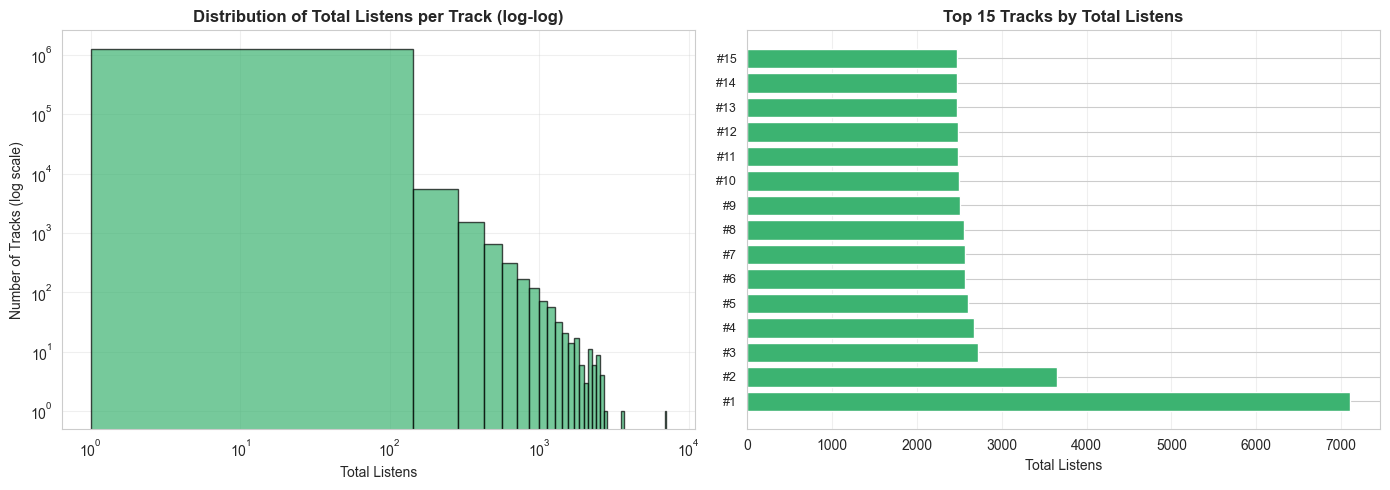


Track Listen Summary:
count    1.285463e+06
mean     7.110205e+00
std      3.620023e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      7.101000e+03
Name: total_listens, dtype: float64


In [18]:
print("\nTRACK STATISTICS")
print("-" * 80)

conn = connect_postgres()

# Load track-level aggregates
with conn.cursor() as cur:
    cur.execute("""
        SELECT 
            recording_id,
            SUM(listen_count) as total_listens,
            COUNT(DISTINCT day) as days_active,
            COUNT(*) as day_entries
        FROM track_daily_listens
        GROUP BY recording_id
        ORDER BY total_listens DESC;
    """)
    track_aggregates = cur.fetchall()

conn.close()

df_tracks = pd.DataFrame(track_aggregates, columns=["recording_id", "total_listens", "days_active", "day_entries"])

print(f"\nTrack Statistics:")
print(f"  Total tracks: {len(df_tracks):,}")
print(f"  Total track-day entries: {df_tracks['day_entries'].sum():,}")
print(f"  Average listens per track: {df_tracks['total_listens'].mean():.0f}")

# Track listen distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale)
axes[0].hist(df_tracks["total_listens"], bins=50, edgecolor="black", alpha=0.7, color="mediumseagreen")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_title("Distribution of Total Listens per Track (log-log)", fontweight="bold")
axes[0].set_xlabel("Total Listens")
axes[0].set_ylabel("Number of Tracks (log scale)")
axes[0].grid(True, alpha=0.3)

# Top tracks
top_n = 15
df_tracks["total_listens"] = pd.to_numeric(df_tracks["total_listens"], errors="coerce").fillna(0).astype("int64")
top_tracks = df_tracks.nlargest(top_n, "total_listens")
axes[1].barh(range(len(top_tracks)), top_tracks["total_listens"].values, color="mediumseagreen")
axes[1].set_yticks(range(len(top_tracks)))
axes[1].set_yticklabels([f"#{i+1}" for i in range(len(top_tracks))], fontsize=9)
axes[1].set_title(f"Top {top_n} Tracks by Total Listens", fontweight="bold")
axes[1].set_xlabel("Total Listens")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print(f"\nTrack Listen Summary:")
print(df_tracks["total_listens"].describe())

In [19]:
# Get track names for top 10 tracks
conn = connect_postgres()
with conn.cursor() as cur:
    top_track_ids = tuple(top_tracks.head(10)["recording_id"].tolist())
    cur.execute("""
        SELECT recording_id, track_name
        FROM track_info
        WHERE recording_id = ANY(%s);
    """, (list(top_track_ids),))
    track_names = cur.fetchall()
conn.close()

# Create lookup dict and add names to top_tracks
track_name_dict = {rec_id: name for rec_id, name in track_names}
top_tracks["track_name"] = top_tracks["recording_id"].map(track_name_dict)

print(f"\nTop 10 Tracks:")
print(top_tracks[["track_name", "total_listens", "days_active"]].head(10).to_string(index=False))


Top 10 Tracks:
       track_name  total_listens  days_active
            Intro           7101         3091
             Home           3647         2136
   Brahms Lullaby           2727          642
          Goodbye           2676         1237
           Closer           2602         1649
             Time           2568         1620
             Numb           2566         1640
 Hush Little Baby           2555          638
Hey Diddle Diddle           2504          567
         Memories           2500         1422



UNIQUE ARTISTS & TRACKS PER DAY (2026-01-01 onwards)


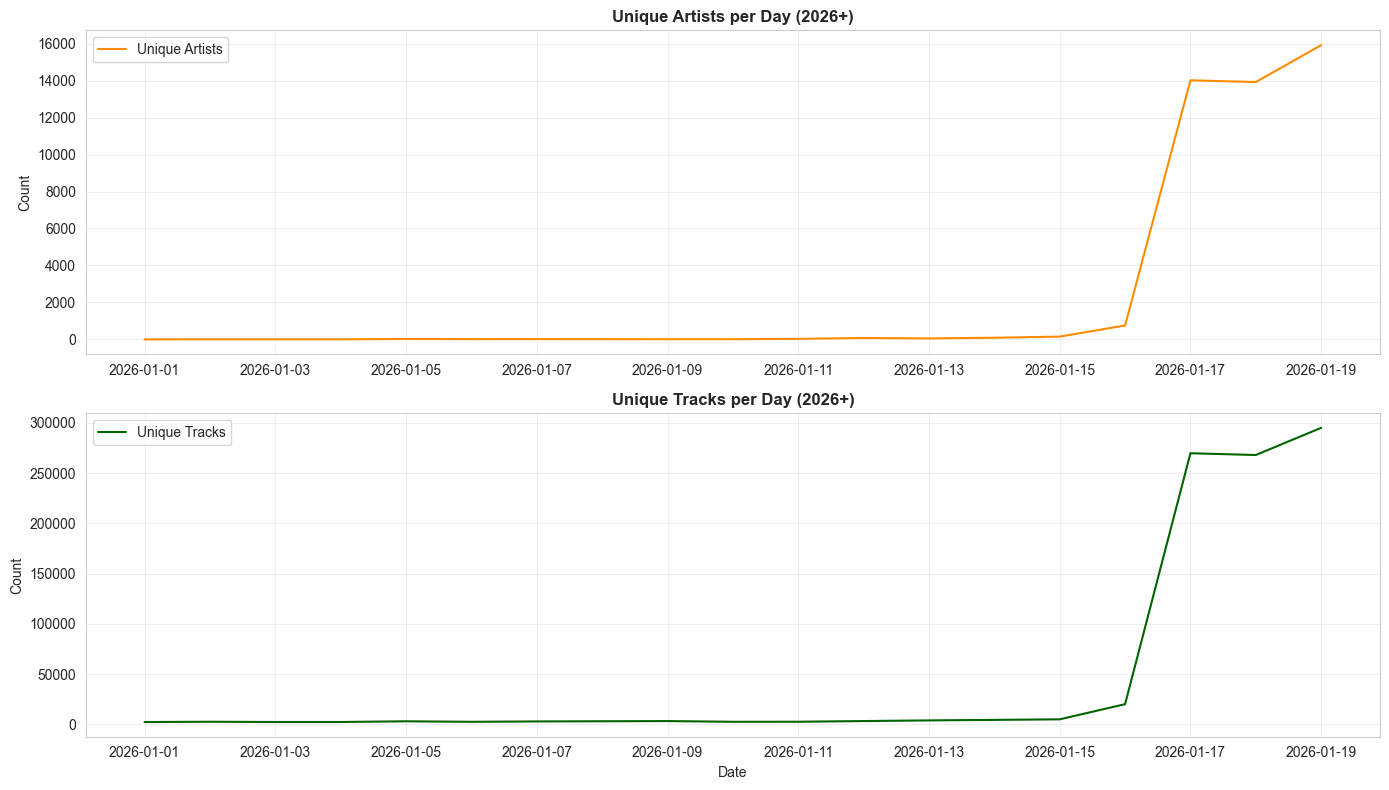


Daily Entity Summary (2026+):
  Artists per day - Mean: 2373, Median: 20
  Tracks per day  - Mean: 47258, Median: 2975


In [25]:
print("\n" + "=" * 80)
print("UNIQUE ARTISTS & TRACKS PER DAY (2026-01-01 onwards)")
print("=" * 80)

conn = connect_postgres()

with conn.cursor() as cur:
    cur.execute("""
        WITH artist_daily AS (
            SELECT
                day,
                COUNT(DISTINCT artist_mbid) AS num_artists
            FROM artist_daily_listens
            WHERE day >= '2026-01-01'
            GROUP BY day
        ),
        track_daily AS (
            SELECT
                day,
                COUNT(DISTINCT recording_id) AS num_tracks
            FROM track_daily_listens
            WHERE day >= '2026-01-01'
            GROUP BY day
        )
        SELECT
            COALESCE(a.day, t.day) AS day,
            COALESCE(a.num_artists, 0) AS num_artists,
            COALESCE(t.num_tracks, 0) AS num_tracks
        FROM artist_daily a
        FULL OUTER JOIN track_daily t
            ON a.day = t.day
        ORDER BY day;
    """)
    daily_entities_2026 = cur.fetchall()

conn.close()

df_entities_2026 = pd.DataFrame(daily_entities_2026, columns=["day", "num_artists", "num_tracks"])
df_entities_2026["day"] = pd.to_datetime(df_entities_2026["day"])
df_entities_2026 = df_entities_2026.sort_values("day")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_entities_2026["day"], df_entities_2026["num_artists"], linewidth=1.5, color="darkorange", label="Unique Artists")
axes[0].set_title("Unique Artists per Day (2026+)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_entities_2026["day"], df_entities_2026["num_tracks"], linewidth=1.5, color="darkgreen", label="Unique Tracks")
axes[1].set_title("Unique Tracks per Day (2026+)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nDaily Entity Summary (2026+):")
print(f"  Artists per day - Mean: {df_entities_2026['num_artists'].mean():.0f}, Median: {df_entities_2026['num_artists'].median():.0f}")
print(f"  Tracks per day  - Mean: {df_entities_2026['num_tracks'].mean():.0f}, Median: {df_entities_2026['num_tracks'].median():.0f}")


DISTRIBUTIONS OF DAILY STATISTICS
--------------------------------------------------------------------------------


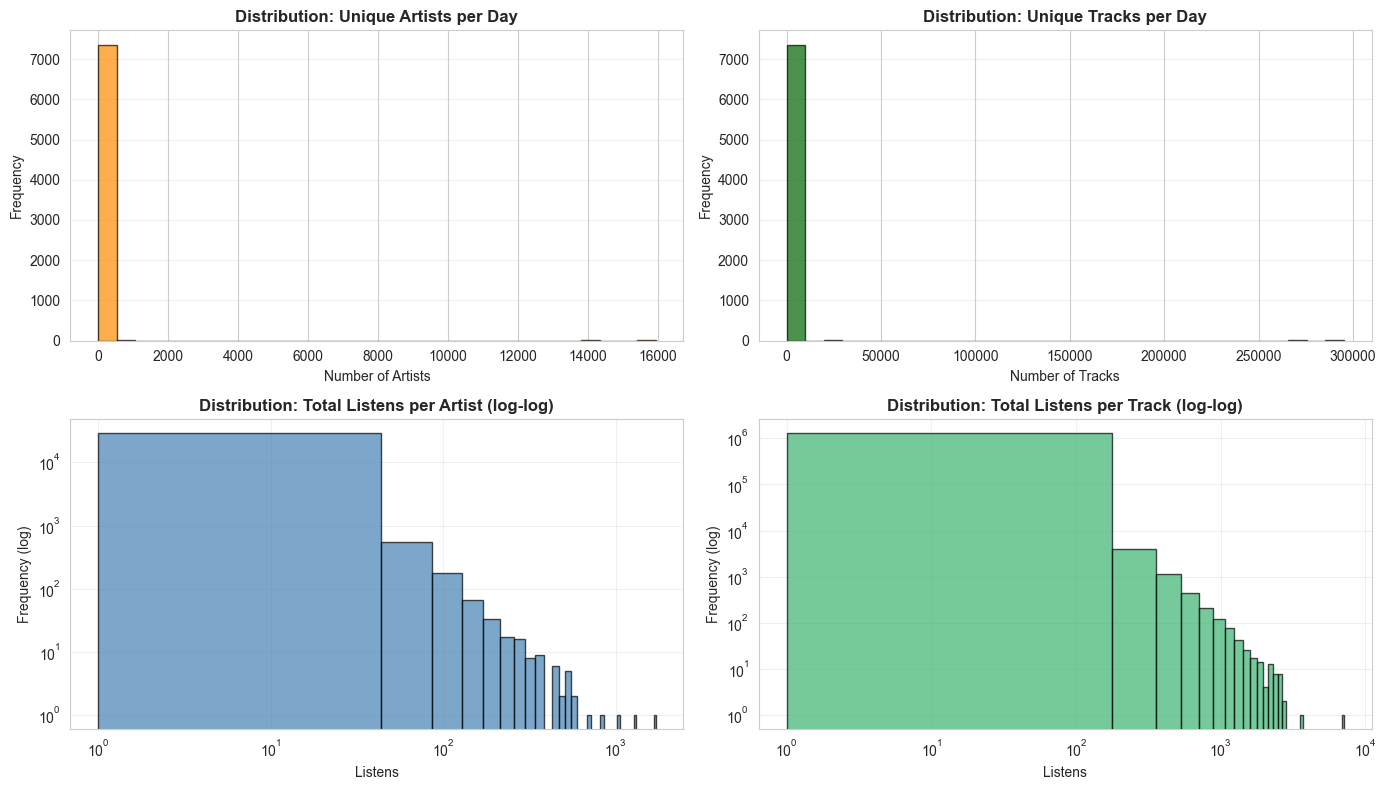

In [26]:
print("\nDISTRIBUTIONS OF DAILY STATISTICS")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histogram: unique artists per day
axes[0, 0].hist(df_entities["num_artists"], bins=30, edgecolor="black", alpha=0.7, color="darkorange")
axes[0, 0].set_title("Distribution: Unique Artists per Day", fontweight="bold")
axes[0, 0].set_xlabel("Number of Artists")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Histogram: unique tracks per day
axes[0, 1].hist(df_entities["num_tracks"], bins=30, edgecolor="black", alpha=0.7, color="darkgreen")
axes[0, 1].set_title("Distribution: Unique Tracks per Day", fontweight="bold")
axes[0, 1].set_xlabel("Number of Tracks")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Histogram: artist listen counts (log scale)
axes[1, 0].hist(df_artists["total_listens"], bins=40, edgecolor="black", alpha=0.7, color="steelblue")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Distribution: Total Listens per Artist (log-log)", fontweight="bold")
axes[1, 0].set_xlabel("Listens")
axes[1, 0].set_ylabel("Frequency (log)")
axes[1, 0].grid(True, alpha=0.3)

# Histogram: track listen counts (log scale)
axes[1, 1].hist(df_tracks["total_listens"], bins=40, edgecolor="black", alpha=0.7, color="mediumseagreen")
axes[1, 1].set_yscale("log")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Distribution: Total Listens per Track (log-log)", fontweight="bold")
axes[1, 1].set_xlabel("Listens")
axes[1, 1].set_ylabel("Frequency (log)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


CUMULATIVE DISTRIBUTIONS (CDF)
--------------------------------------------------------------------------------


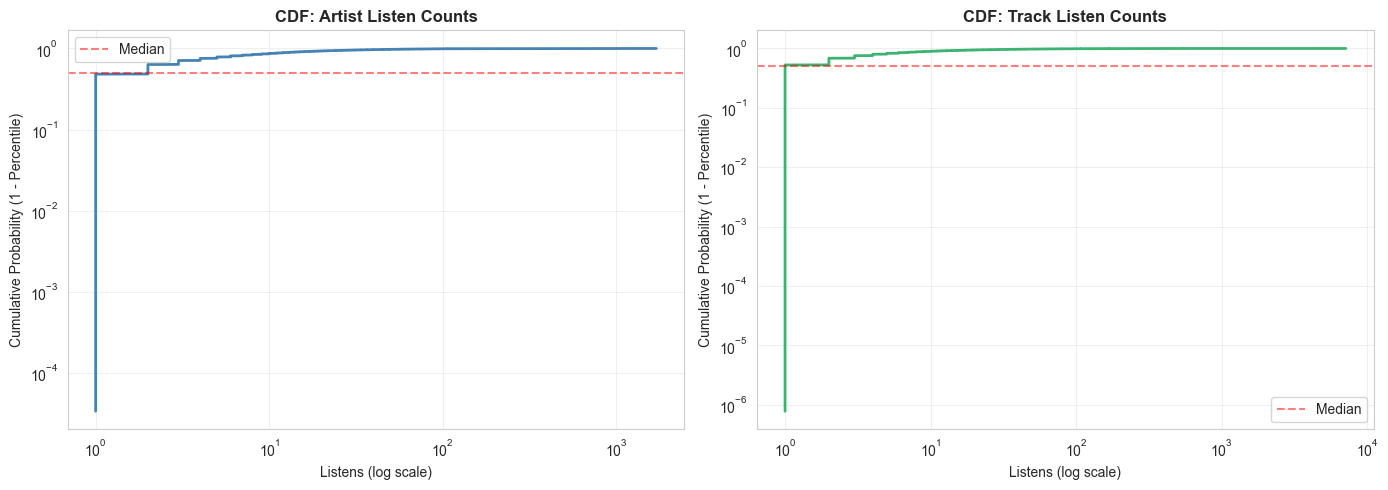

In [27]:
print("\nCUMULATIVE DISTRIBUTIONS (CDF)")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CDF: Artists
sorted_artist = np.sort(df_artists["total_listens"].values)
cdf_artist = np.arange(1, len(sorted_artist) + 1) / len(sorted_artist)
axes[0].loglog(sorted_artist, cdf_artist, linewidth=2, color="steelblue")
axes[0].set_title("CDF: Artist Listen Counts", fontweight="bold")
axes[0].set_xlabel("Listens (log scale)")
axes[0].set_ylabel("Cumulative Probability (1 - Percentile)")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Median")
axes[0].legend()

# CDF: Tracks
sorted_track = np.sort(df_tracks["total_listens"].values)
cdf_track = np.arange(1, len(sorted_track) + 1) / len(sorted_track)
axes[1].loglog(sorted_track, cdf_track, linewidth=2, color="mediumseagreen")
axes[1].set_title("CDF: Track Listen Counts", fontweight="bold")
axes[1].set_xlabel("Listens (log scale)")
axes[1].set_ylabel("Cumulative Probability (1 - Percentile)")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Median")
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase 5: Computed Statistics Analysis (if available)

In [4]:
print("\n" + "=" * 80)
print("PHASE 5: COMPUTED STATISTICS ANALYSIS")
print("=" * 80)

conn = connect_postgres()

# Check if stats tables have data
with conn.cursor() as cur:
    cur.execute("SELECT COUNT(*) FROM artist_daily_stats;")
    stats_count = cur.fetchone()[0]

conn.close()

if stats_count > 0:
    print("\nStats tables are populated. Loading artist_daily_stats...")
    
    conn = connect_postgres()
    with conn.cursor() as cur:
        cur.execute("""
            SELECT day, artist_mbid, growth_percentile, cumulative_listen_count,
                   listen_count_past_7_days, listen_pctl_past_7_days,
                   listen_count_past_30_days, listen_pctl_past_30_days
            FROM artist_daily_stats
            ORDER BY day;
        """)
        stats_data = cur.fetchall()
    conn.close()
    
    df_stats = pd.DataFrame(stats_data, columns=[
        "day", "artist_mbid", "growth_percentile", "cumulative_listen_count",
        "listen_count_past_7_days", "listen_pctl_past_7_days",
        "listen_count_past_30_days", "listen_pctl_past_30_days"
    ])
    df_stats["day"] = pd.to_datetime(df_stats["day"])
    
    print(f"Loaded {len(df_stats):,} rows from artist_daily_stats")
    
    # Basic stats
    print(f"\nArtist Daily Stats Summary:")
    print(f"  Growth percentile - Mean: {df_stats['growth_percentile'].mean():.3f}")
    print(f"  Cumulative listens - Mean: {df_stats['cumulative_listen_count'].mean():.0f}")
    print(f"  7-day listens - Mean: {df_stats['listen_count_past_7_days'].mean():.0f}")
    print(f"  30-day listens - Mean: {df_stats['listen_count_past_30_days'].mean():.0f}")
    
    # Check validity: cumulative should be non-decreasing
    issue_count = 0
    for artist in df_stats["artist_mbid"].unique()[:100]:  # Check first 100 artists
        artist_data = df_stats[df_stats["artist_mbid"] == artist].sort_values("day")
        diffs = artist_data["cumulative_listen_count"].diff()
        if (diffs < 0).any():
            issue_count += 1
    print(f"  Soundness check: {issue_count} artists have decreasing cumulative counts (should be 0 or very few)")
    
else:
    print("Stats tables appear to be empty. Skipping stats analysis.")
    df_stats = None


PHASE 5: COMPUTED STATISTICS ANALYSIS

Stats tables are populated. Loading artist_daily_stats...
Loaded 45,261 rows from artist_daily_stats

Artist Daily Stats Summary:
  Growth percentile - Mean: 0.257
  Cumulative listens - Mean: 8
  7-day listens - Mean: 8
  30-day listens - Mean: 8
  Soundness check: 0 artists have decreasing cumulative counts (should be 0 or very few)



STATISTICS DISTRIBUTIONS
--------------------------------------------------------------------------------


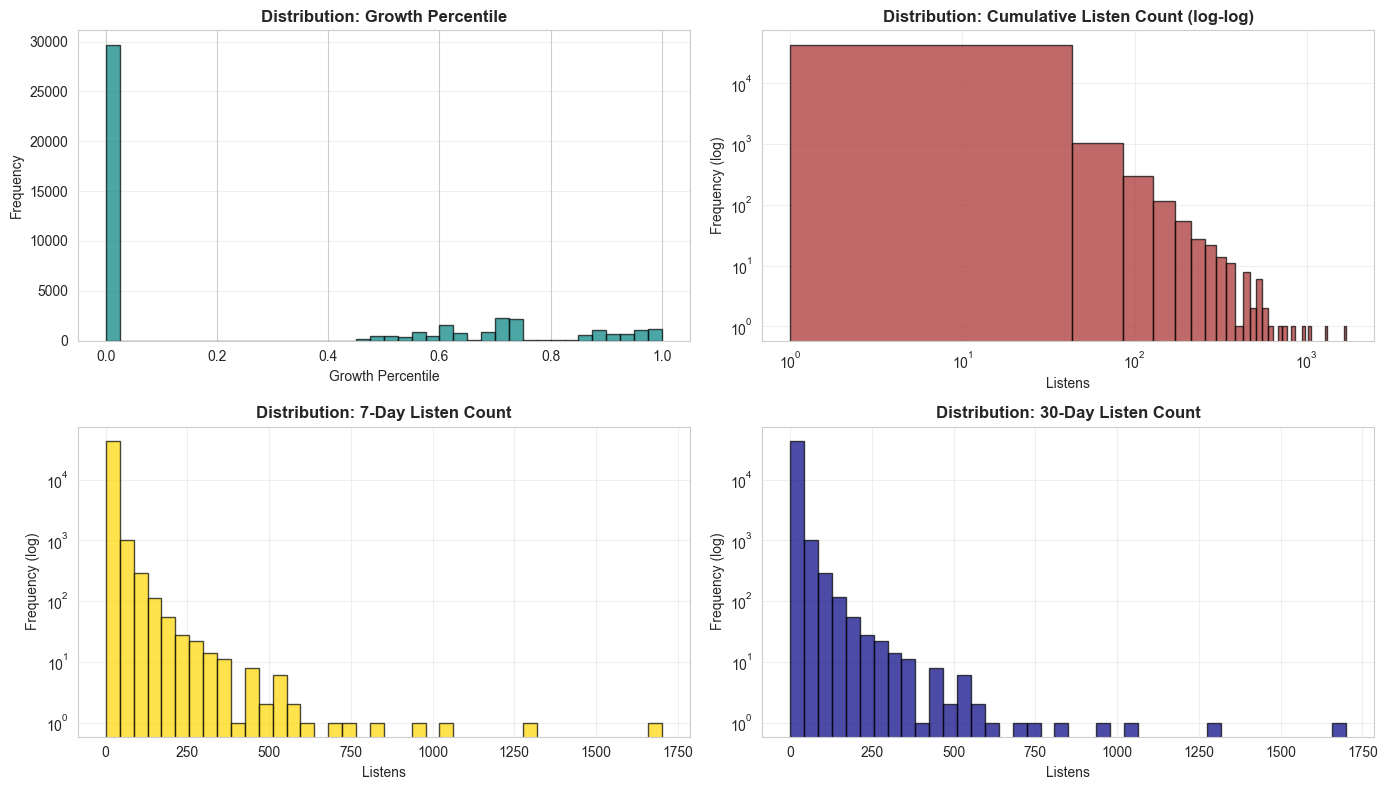

In [5]:
if df_stats is not None and len(df_stats) > 0:
    print("\nSTATISTICS DISTRIBUTIONS")
    print("-" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Growth percentile
    axes[0, 0].hist(df_stats['growth_percentile'].dropna(), bins=40, edgecolor="black", alpha=0.7, color="teal")
    axes[0, 0].set_title("Distribution: Growth Percentile", fontweight="bold")
    axes[0, 0].set_xlabel("Growth Percentile")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 0].grid(True, alpha=0.3, axis="y")
    
    # Cumulative listen count (log scale)
    axes[0, 1].hist(df_stats['cumulative_listen_count'], bins=40, edgecolor="black", alpha=0.7, color="brown")
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_title("Distribution: Cumulative Listen Count (log-log)", fontweight="bold")
    axes[0, 1].set_xlabel("Listens")
    axes[0, 1].set_ylabel("Frequency (log)")
    axes[0, 1].grid(True, alpha=0.3)
    
    # 7-day listens
    axes[1, 0].hist(df_stats['listen_count_past_7_days'], bins=40, edgecolor="black", alpha=0.7, color="gold")
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_title("Distribution: 7-Day Listen Count", fontweight="bold")
    axes[1, 0].set_xlabel("Listens")
    axes[1, 0].set_ylabel("Frequency (log)")
    axes[1, 0].grid(True, alpha=0.3)
    
    # 30-day listens
    axes[1, 1].hist(df_stats['listen_count_past_30_days'], bins=40, edgecolor="black", alpha=0.7, color="navy")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Distribution: 30-Day Listen Count", fontweight="bold")
    axes[1, 1].set_xlabel("Listens")
    axes[1, 1].set_ylabel("Frequency (log)")
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()